# Task 3: Data Cleaning (Object Detection)
This notebook implements the AIN7101 Data Cleaning rubric, adapted for 4K Boreal Forest Fire images.
It applies a sequence-aware, 7-part cleaning pipeline.

In [1]:
import os
import glob
import hashlib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat
import imagehash

# Suppress DecompressionBombWarning for large 4K images
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

base_dir = r"d:\Masters Academy AI\Advanced Techniques in Object Detection and Recognition\Research Paper\dataset-b\raw\Boreal-Forest-Fire-Subset-A"
log_data = []  # To store the audit log [Step, Image, Issue Type, Detection Method, Treatment, Rationale]


## Part 1: Missing Values & Integrity (MCAR/MAR)

In [2]:
# Get all images and labels
image_files = sorted(glob.glob(os.path.join(base_dir, "*-Images", "*.jpg")))
label_files = sorted(glob.glob(os.path.join(base_dir, "*-Labels", "*.txt")))

image_stems = {os.path.splitext(os.path.basename(f))[0]: f for f in image_files}
label_stems = {os.path.splitext(os.path.basename(f))[0]: f for f in label_files}

valid_pairs = []

for stem in set(image_stems.keys()).union(set(label_stems.keys())):
    img_path = image_stems.get(stem)
    lbl_path = label_stems.get(stem)
    
    if not img_path:
        log_data.append(["Part 1", stem, "Missing Image", "File exist check", "Deleted label", "MCAR: Cannot train without image"])
        if lbl_path and os.path.exists(lbl_path): os.remove(lbl_path)
        continue
    if not lbl_path:
        log_data.append(["Part 1", stem, "Missing Label", "File exist check", "Deleted image", "MCAR: Cannot train without label"])
        if img_path and os.path.exists(img_path): os.remove(img_path)
        continue
        
    # Check 0-bytes
    if os.path.getsize(img_path) == 0:
        log_data.append(["Part 1", stem, "Corrupt Image", "0-byte check", "Deleted pair", "Image is empty"])
        os.remove(img_path)
        os.remove(lbl_path)
        continue
        
    # PIL Verify
    try:
        with Image.open(img_path) as img:
            img.verify()
        valid_pairs.append((img_path, lbl_path))
    except Exception as e:
        log_data.append(["Part 1", stem, "Corrupt Image", "PIL verify", "Deleted pair", f"Unreadable file: {str(e)}"])
        os.remove(img_path)
        os.remove(lbl_path)

print(f"Started with {len(image_files)} images and {len(label_files)} labels.")
print(f"Valid paired files after Part 1: {len(valid_pairs)}")


Started with 4954 images and 4954 labels.
Valid paired files after Part 1: 4954


## Part 2: Exact Duplicates

In [3]:
# MD5 Hash check
md5_hashes = {}
unique_pairs = []

for img_path, lbl_path in valid_pairs:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    with open(img_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        
    if file_hash in md5_hashes:
        log_data.append(["Part 2", stem, "Exact Duplicate", "MD5 Hash", "Deleted pair", f"Duplicate of {md5_hashes[file_hash]}"])
        os.remove(img_path)
        os.remove(lbl_path)
    else:
        md5_hashes[file_hash] = stem
        unique_pairs.append((img_path, lbl_path))
        
print(f"Unique files after MD5 check: {len(unique_pairs)}")


Unique files after MD5 check: 4954


## Part 3 & 4: Noisy Data, Outliers, and Consistency

In [4]:
import copy

final_pairs = []
areas = []
aspect_ratios = []
blur_scores = []

# First pass: collect stats to compute percentiles/IQR
for img_path, lbl_path in unique_pairs:
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            _, _, _, w, h = map(float, parts)
            areas.append(w * h)
            if h > 0: aspect_ratios.append(w / h)

area_p01 = np.percentile(areas, 0.01) if areas else 0
area_p995 = np.percentile(areas, 99.5) if areas else 1
q1, q3 = np.percentile(aspect_ratios, [25, 75]) if aspect_ratios else (0,1)
iqr = q3 - q1
ar_lower = q1 - 1.5 * iqr
ar_upper = q3 + 1.5 * iqr

for img_path, lbl_path in unique_pairs:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    
    # 1. Blur & Contrast Check
    img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_cv is not None:
        laplacian_var = cv2.Laplacian(img_cv, cv2.CV_64F).var()
        blur_scores.append(laplacian_var)
        if laplacian_var < 50:
            log_data.append(["Part 3", stem, "Blurry Image", "Laplacian Var < 50", "Flagged", "Loss of 4K texture"])
    
    # 2. Bounding Box Validity
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
        
    new_lines = []
    file_modified = False
    
    for idx, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) != 5:
            log_data.append(["Part 4", stem, "Invalid Format", "Word count != 5", "Deleted annotation", "YOLO format corruption"])
            file_modified = True
            continue
            
        cls_id, cx, cy, w, h = map(float, parts)
        
        # Auto-correct class ID
        if cls_id != 0:
            cls_id = 0
            log_data.append(["Part 4", stem, "Wrong Class ID", "cls != 0", "Auto-corrected to 0", "Single class unification"])
            file_modified = True
            
        # Degenerate boxes
        if w <= 0 or h <= 0:
            log_data.append(["Part 3", stem, "Degenerate Box", "w or h <= 0", "Deleted annotation", "Zero area box"])
            file_modified = True
            continue
            
        # 2-Tier Out-of-Bounds Logic
        coords = [cx, cy, w, h]
        out_of_bounds = False
        large_error = False
        for i, val in enumerate(coords):
            if val < 0 or val > 1:
                margin = max(abs(0 - val), abs(1 - val))
                if margin >= 0.02:
                    large_error = True
                else:
                    coords[i] = max(0.0, min(1.0, val))
                    out_of_bounds = True
        
        if large_error:
            log_data.append(["Part 4", stem, "OOB Coords (Large)", "margin >= 0.02", "Deleted annotation", "Clipping shifts ground truth"])
            file_modified = True
            continue
        elif out_of_bounds:
            log_data.append(["Part 4", stem, "OOB Coords (Small)", "margin < 0.02", "Clipped to [0,1]", "Negligible shift"])
            file_modified = True
            cx, cy, w, h = coords
            
        # Area Outliers (Percentile)
        area = w * h
        if area < max(area_p01, 0.0001) or area > min(area_p995, 0.95):
            log_data.append(["Part 3", stem, "Area Outlier", "Percentile Bounds", "Flagged", f"Area: {area:.4f}"])
            
        # Aspect Ratio Outliers (IQR)
        ar = w / h
        if ar < ar_lower or ar > ar_upper:
            log_data.append(["Part 3", stem, "AR Outlier", "IQR Bounds", "Flagged", f"AR: {ar:.2f}"])
            
        new_lines.append(f"{int(cls_id)} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        
    if file_modified:
        with open(lbl_path, 'w') as f:
            f.writelines(new_lines)
            
    final_pairs.append((img_path, lbl_path))
    
print("Finished noise and validity checks.")


Finished noise and validity checks.


## Part 5: Sequential Consistency (Video-Aware)

In [5]:
# Extract video clips
from collections import defaultdict

# Group frames by clip prefix
clips = defaultdict(list)
for img_path, lbl_path in final_pairs:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    clip_prefix = "_".join(stem.split('_')[:-1])  # e.g., evoDJI_0001
    clips[clip_prefix].append((img_path, lbl_path, stem))
    
# Sort each clip chronologically
for prefix in clips:
    clips[prefix].sort(key=lambda x: x[2])
    
# Calculate Sequence IoU and pHash
def bb_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

for prefix, frames in clips.items():
    # Box count mode check
    box_counts = []
    for _, lbl_path, _ in frames:
        with open(lbl_path, 'r') as f:
            box_counts.append(len(f.readlines()))
    
    if len(box_counts) > 0:
        import statistics
        try: mode_count = statistics.mode(box_counts)
        except: mode_count = box_counts[0]
        
        for idx, count in enumerate(box_counts):
            if abs(count - mode_count) > 0: # Note: user requested we just flag these, not delete
                log_data.append(["Part 4", frames[idx][2], "Box Count Shift", "Mode deviation", "Flagged", "Smoke might have dissipated or annotation error"])
                
    # Sequential checks (pHash and IoU)
    for i in range(1, len(frames)):
        prev_img, prev_lbl, prev_stem = frames[i-1]
        curr_img, curr_lbl, curr_stem = frames[i]
        
        # pHash
        try:
            hash0 = imagehash.phash(Image.open(prev_img))
            hash1 = imagehash.phash(Image.open(curr_img))
            if hash0 - hash1 < 5:
                log_data.append(["Part 5", curr_stem, "Near Duplicate", "pHash < 5", "Flagged", "Temporal static scene"])
        except: pass
        
        # IoU Jumps (only if both have 1 box)
        if box_counts[i-1] == 1 and box_counts[i] == 1:
            with open(prev_lbl, 'r') as f: b0 = list(map(float, f.readline().strip().split()[1:]))
            with open(curr_lbl, 'r') as f: b1 = list(map(float, f.readline().strip().split()[1:]))
            
            # yolo cx, cy, w, h to x1, y1, x2, y2
            box0 = [b0[0]-b0[2]/2, b0[1]-b0[3]/2, b0[0]+b0[2]/2, b0[1]+b0[3]/2]
            box1 = [b1[0]-b1[2]/2, b1[1]-b1[3]/2, b1[0]+b1[2]/2, b1[1]+b1[3]/2]
            
            iou = bb_iou(box0, box1)
            if iou < 0.5:
                log_data.append(["Part 5", curr_stem, "Box Jump", "Consecutive IoU < 0.5", "Flagged", f"IoU: {iou:.2f}"])

print("Sequential checks completed.")


Sequential checks completed.


## Part 6: Data Drift Awareness
Based on Task 2, we identified:
1. **Temporal Drift:** Mean box displacement of 0.041 between frames.
2. **Illumination Drift:** Brightness bias towards daytime (mean 110/255).
3. **Spatial Drift:** Horizon bias (mean Y-center = 0.395).

Static global imputation (which we rejected) would fail to account for these dynamic shifts across video sequences.

## Part 7: Logging and Visualization

Total flags/modifications logged: 4137


,Step,Image,Issue Type,Detection Method,Treatment,Rationale
0,Part 3,heinola_DJI_0036_frame108,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
1,Part 3,evoDJI_0009_frame82,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
2,Part 3,heinola_DJI_0033_frame190,AR Outlier,IQR Bounds,Flagged,AR: 1.53
3,Part 3,evoDJI_0009_frame281,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
4,Part 3,evoDJI_0009_frame281,AR Outlier,IQR Bounds,Flagged,AR: 1.97
5,Part 3,heinola_DJI_0030_frame93,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
6,Part 3,evoDJI_0009_frame74,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
7,Part 3,evoDJI_0009_frame170,AR Outlier,IQR Bounds,Flagged,AR: 1.82
8,Part 3,evoDJI_0009_frame124,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
9,Part 3,evoDJI_0009_frame124,AR Outlier,IQR Bounds,Flagged,AR: 1.54


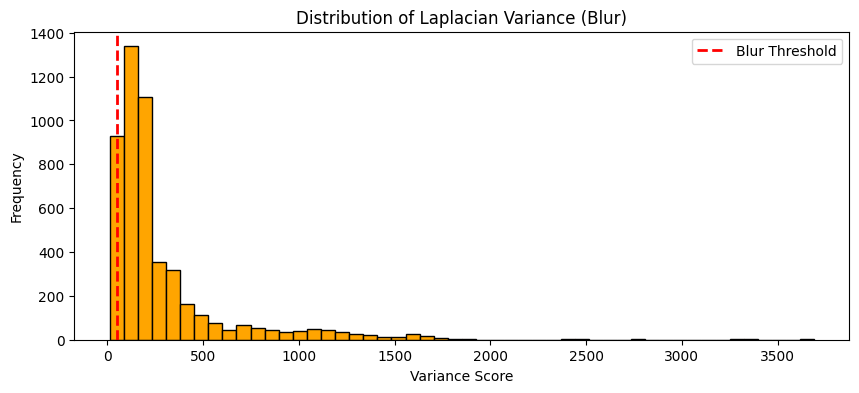

In [6]:
# DataFrame Export
df_log = pd.DataFrame(log_data, columns=["Step", "Image", "Issue Type", "Detection Method", "Treatment", "Rationale"])
df_log.to_csv("cleaning_log.csv", index=False)

print(f"Total flags/modifications logged: {len(df_log)}")
display(df_log.head(10))

# Plotting Blur
plt.figure(figsize=(10,4))
plt.hist(blur_scores, bins=50, color='orange', edgecolor='black')
plt.axvline(50, color='red', linestyle='dashed', linewidth=2, label='Blur Threshold')
plt.title("Distribution of Laplacian Variance (Blur)")
plt.xlabel("Variance Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("blur_dist.png")
plt.show()
